# PROC LOESSによるノイズの多い工程センサー信号のノイズ除去

## 概要

製造ラインの炉内温度センサーは、起動時に1秒ごとにサンプリングされるため、各読み取り値は緩やかな非線形の熱過渡現象(急速な昇温、行き過ぎのオーバーシュート、300°Cの設定値へ向けた復帰)と、かなりの測定ノイズが混ざり合ったものになる。本ノートブックでは**PROC LOESS**を用いてノンパラメトリックに真の信号を復元する。100サンプルのログでは、AICCが平滑化パラメータ0.08(等価パラメータ数8)を選択し、得られた曲線は潜在信号を忠実に追跡し、残差の標準偏差は3.10°C——注入した4°Cのノイズからフィットが説明した分散を差し引いた分にほぼ等しい——となった。既知の真値と比較すると、LOESS推定は平均二乗誤差を14.77(生データ)から6.63に削減し、SCOREステップはノイズ除去後の信号を均一な監視グリッドに再サンプリングし、下流の統計的工程管理に供する。

## データソース

| データセット | 行数 | 変数 | 説明 |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t`(経過秒数、0〜99)、`temp`(観測された炉内温度、°C)、`truth`(検証用の潜在ノイズなし信号) | 1秒ごとに1サンプルの合成炉センサーログ。潜在信号は、300°Cの設定値に向かう急速な昇温ランプに、t=28付近(約295°C)でピークを迎える減衰オーバーシュートが加わり、その後谷を経て設定値へ落ち着く形をとる。観測される`temp`にはガウス測定ノイズ(標準偏差 約4°C)が加わる。 |
| `grid` | 60 | `t`(均一な0〜99の監視グリッド) | SCOREステートメントが均等間隔のノイズ除去済み信号をSPCチャート用に出力するために使う規則的な時間グリッド。 |

製造ラインでは、炉内センサーが起動時に1秒ごとに温度を記録する。記録される読み取り値は、**真の熱状態に測定ノイズが加わったもの**である。真の状態はきれいなパラメトリック式には従わない——昇温時にランプ状に上昇し、設定値をオーバーシュートし、その後落ち着く——ため、大域的な線形や多項式のフィットでは良いモデルにならない。

**局所回帰(LOESS)**はまさに適したツールである:低次多項式をスライドする局所近傍にフィットさせることで、関数形を指定することなく任意の滑らかな信号を復元する。ここでは以下を行う:

1. 現実的なノイズを含む100サンプルのセンサーログをシミュレートする。
2. `PROC LOESS`にAICC基準で自身の平滑化バンド幅を選ばせる。
3. フィットした信号に95%信頼帯を付与する。
4. 下流のSPC向けに規則的なグリッド上でモデルをスコアリングする。
5. どれだけノイズを除去できたかを定量化する。

## ステップ1 — センサーログをシミュレートする

0〜99秒にわたる100サンプルを生成する。潜在信号`truth`は、300°Cの設定値に向かう急速な昇温ランプに減衰オーバーシュートが加わったもの——直線や単一の多項式ではうまく捉えられない形状——で、急激に立ち上がり、t=28付近で設定値を超えてピークに達し、谷を経て設定値へ落ち着く。観測される`temp`にはガウス測定ノイズが加わる。`call streaminit`でシードを固定し、実行を再現可能にする。

In [1]:
データ sensor;
    呼出 streaminit(70421);
    setpoint = 300;
    繰返 t = 0 から 99;
        /* 潜在信号: 急速な昇温ランプ + 減衰する行き過ぎのオーバーシュート */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* 観測値 = 真値 + 測定ノイズ(標準偏差 約4°C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        出力;
    終了;
    保持 t TEMP truth;
実行;

処理 印刷 データ=sensor(obs=8) noobs 見出;
    見出 t='経過時間(秒)' TEMP='観測温度(°C)' truth='真の信号(°C)';
    表題 '最初の8件のセンサーサンプル';
実行;

                                                     最初の8件のセンサーサンプル                                                     

          経過時間(秒)           観測温度(°C)           真の信号(°C)
                0       0.1684867131                  0
                1      28.1933107495      32.0778466448
                2      61.6123615699      61.2117857105
                3      85.5053781561       87.643846097
                4     110.5560474248     111.5945193774
                5     136.6368358359     133.2650493509
                6     144.2434193147     152.8394750856
                7     177.8286488692     170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## ステップ2 — 生の信号を確認する

簡単な散布図を見ると問題がよく分かる:基礎にある変動は目で見て明らかだが、サンプルごとのノイズに埋もれている。ジグザグした点そのものではなく、滑らかな曲線の推定値が必要である。

                                                     最初の8件のセンサーサンプル                                                     




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


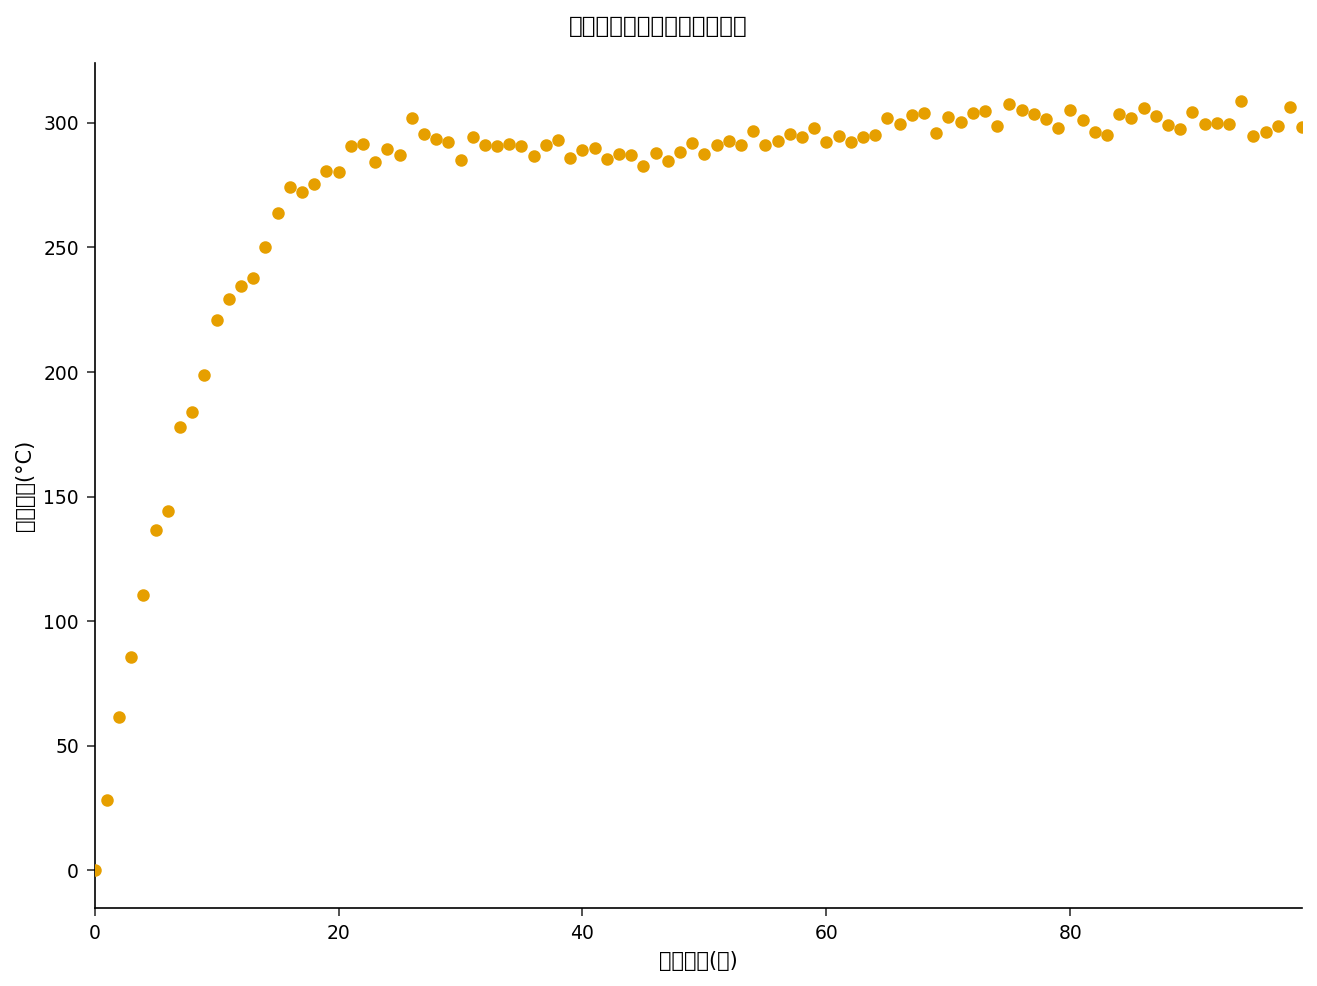

In [2]:
ODS GRAPHICS ON;

処理 SGPLOT データ=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS 見出='経過時間(秒)';
    YAXIS 見出='炉内温度(°C)';
    表題 '炉センサーの生の読み取り値';
実行;

ODS GRAPHICS OFF;

## ステップ3 — 自動バンド幅選択でLOESSをフィットする

平滑化パラメータは各局所近傍の広さを制御する:狭すぎるとノイズに過適合し、広すぎるとオーバーシュートを消してしまう。推測に頼る代わりに、`select=AICC`で**修正赤池情報量規準**を最小化することでLOESSに自動選択させる。局所2次多項式(`degree=2`)を使うことで、曲線が昇温とオーバーシュートの曲率に追従できるようにし、`clm`と`alpha=0.05`で95%信頼帯を要求する。

`ODS OUTPUT`は2つのテーブルをデータセットとして取得する:`OutputStatistics`(各点の平滑化値と残差)と`FitSummary`(選択されたバンド幅とフィット診断)。`OUTPUT`ステートメントは各観測値について予測値・残差・95%信頼限界を含む`fitted`データセットを書き出す——これが後続のプロットの元データとなる。

In [3]:
処理 loess データ=sensor;
    ODS 出力 OutputStatistics=loess_fit
               FitSummary=fit_summary;
    模型 TEMP = t / DEGREE=2 選択=AICC CLM ALPHA=0.05 details;
    出力 out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
実行;

                                                     最初の8件のセンサーサンプル                                                     


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## ステップ4 — 選択されたモデルを確認する

Fit Summaryには、AICC最適な平滑化パラメータと予測行列のトレース(有効自由度、すなわちモデルの複雑さの尺度)が記録される。平滑化パラメータが小さく自由度が大きいほど、フィットはより波打つ。AICCはフィットの良さと複雑さのバランスを自動的に取る。

In [4]:
処理 印刷 データ=fit_summary noobs 見出;
    見出 smoothingparameter='平滑化パラメータ' label1='項目' nvalue1='値';
    表題 'LOESSフィット概要(AICCで選択したバンド幅)';
実行;

                                               LOESSフィット概要(AICCで選択したバンド幅)                                               

                平滑化パラメータ                               項目               値
                    0.08  Residual Sum of Squares          950.8591917253
                    0.08  Equivalent Number of Parameters               8
                    0.08  Delta1                                        8
                    0.08  Delta2                                      7.6
                    0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## ステップ5 — フィットと信頼帯を真値と重ねて確認する

これはシミュレーションデータなので、ノイズを含まない`truth`列を保持している。LOESS推定とその95%信頼帯を`truth`と並べてプロットすることで、平滑化器が一度も直接見ていない潜在信号をどれだけ忠実に復元できたかが分かる。

                                               LOESSフィット概要(AICCで選択したバンド幅)                                               




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


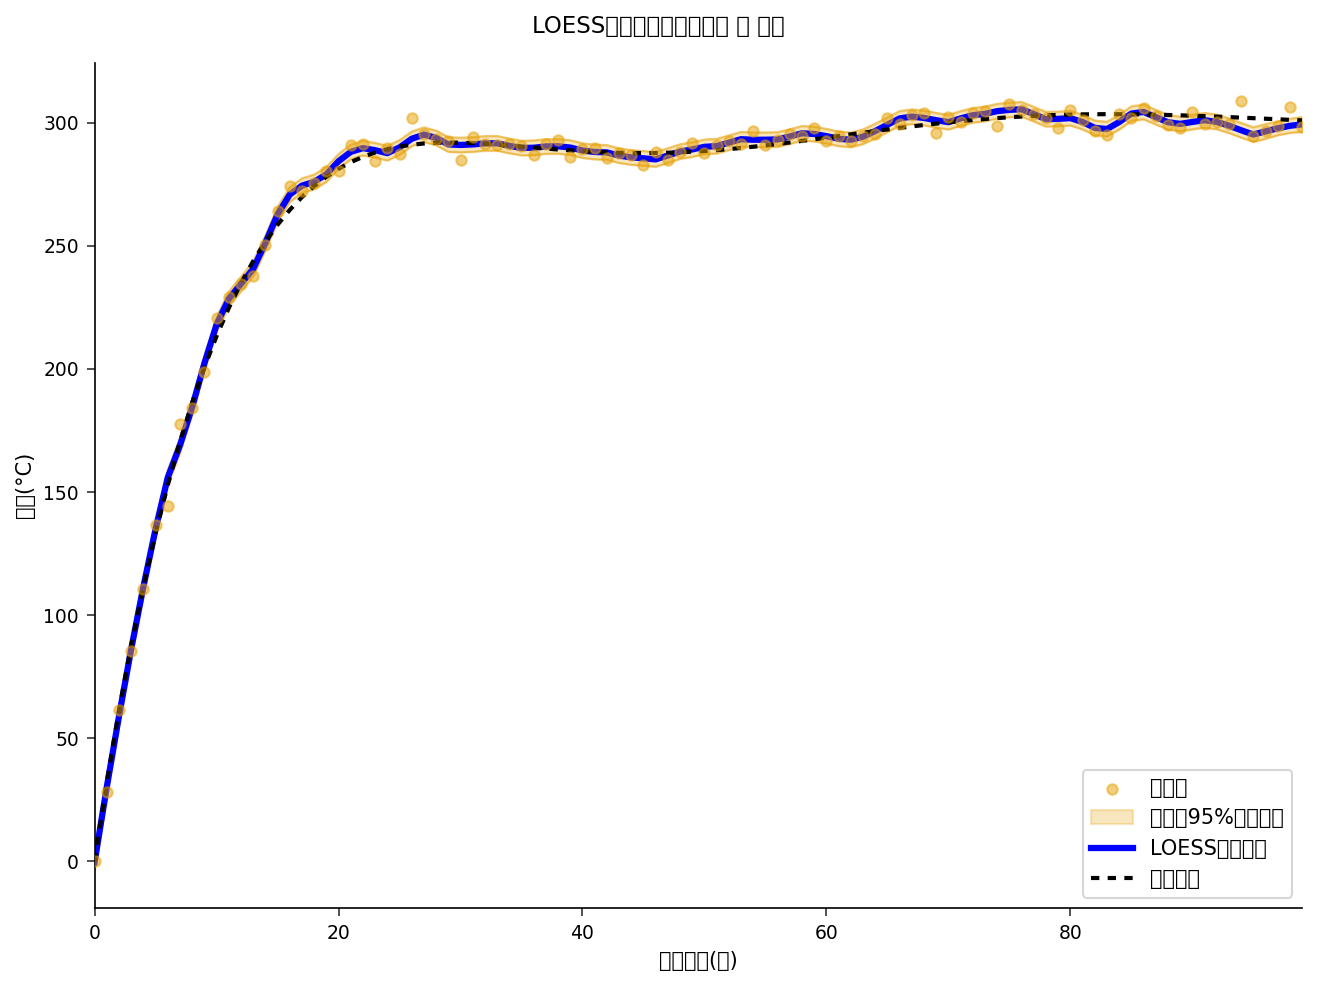

In [5]:
処理 並替 データ=fitted; 基準 t; 実行;

ODS GRAPHICS ON;

処理 SGPLOT データ=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='観測値';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='平均の95%信頼限界';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESSフィット';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='真の信号';
    XAXIS 見出='経過時間(秒)';
    YAXIS 見出='温度(°C)';
    表題 'LOESSノイズ除去後の信号 対 真値';
実行;

ODS GRAPHICS OFF;

## ステップ6 — 残差診断

残差(観測値 − フィット値)は、ゼロを中心とした無構造なノイズのように見えるべきである。傾向が残っていれば、平滑化不足または見落とした特徴を示唆する。残差を時間に対してプロットし、そのばらつきを要約する——残差の標準偏差は3.10°Cとなり、局所フィットがノイズの一部を吸収するため、注入した4°Cのノイズよりわずかに小さい。

                                               LOESSフィット概要(AICCで選択したバンド幅)                                               

                                                    残差要約(復元された測定ノイズ)                                                    

                                                  The MEANS Procedure

 Variable  Label                                         N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------------------------
 RESID     残差(観測 − フィット、°C)                            100       0.139       3.096     -11.688      11.909
 ---------------------------------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


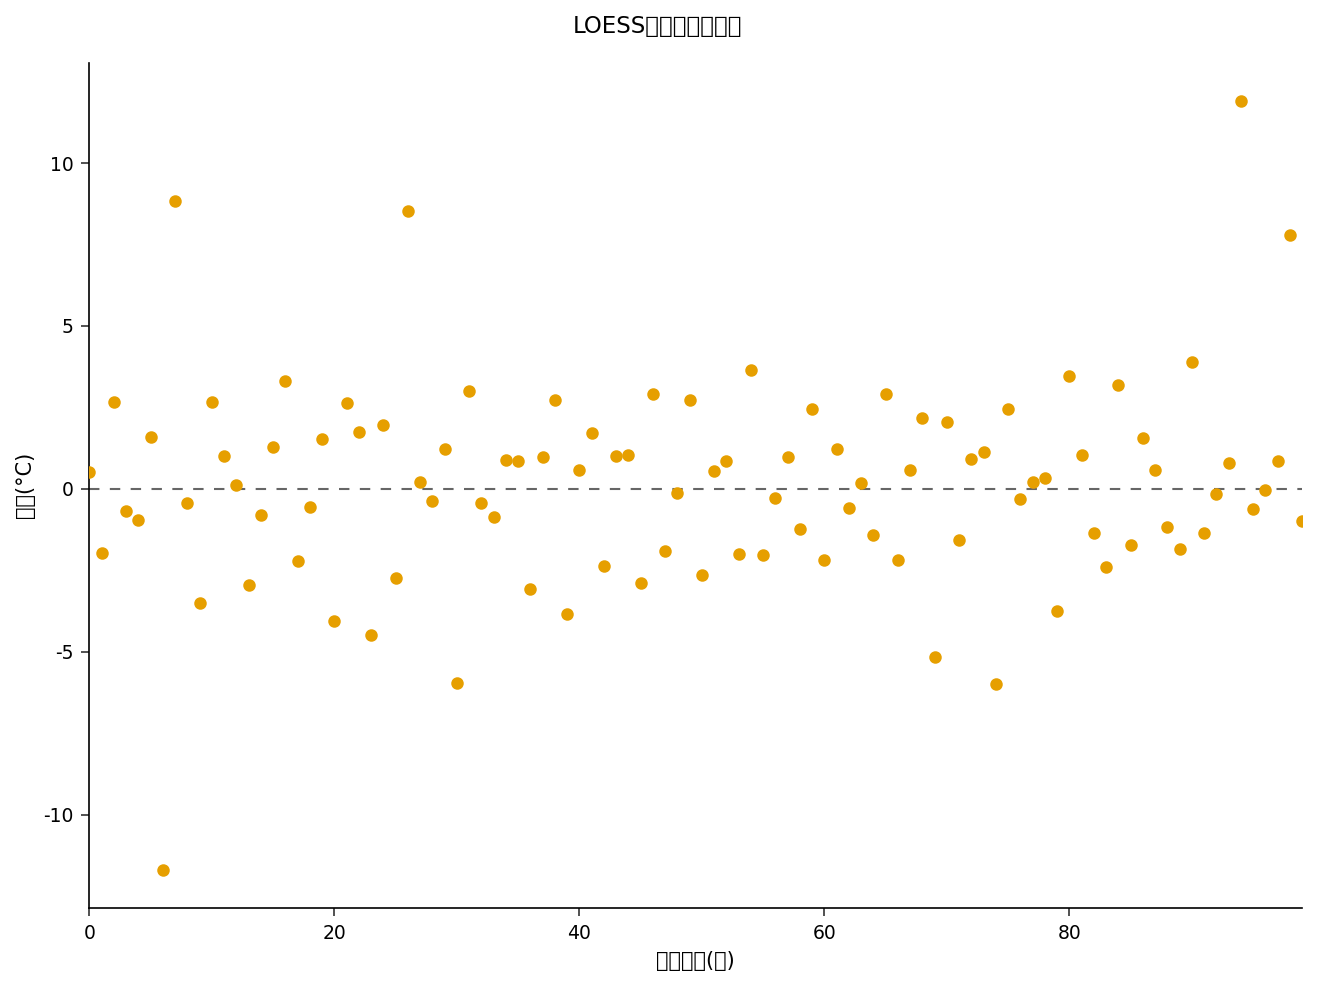

In [6]:
ODS GRAPHICS ON;

処理 SGPLOT データ=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS 見出='経過時間(秒)';
    YAXIS 見出='残差(°C)';
    表題 'LOESS残差の時間推移';
実行;

ODS GRAPHICS OFF;

処理 平均 データ=fitted n mean std MIN MAX maxdec=3;
    変数 resid;
    見出 resid='残差(観測 − フィット、°C)';
    表題 '残差要約(復元された測定ノイズ)';
実行;

## ステップ7 — SPC向けに規則的な監視グリッドをスコアリングする

センサーのタイムスタンプは等間隔である必要はないが、管理図には固定された周期の信号が必要である。均一な60点の時間グリッドを作成し、`SCORE`ステートメントを使ってフィットしたLOESSモデルをそこに適用し、信頼限界も要求する。スコアリングされた値は、SPCルーチンにそのまま投入できる、きれいで等間隔の信号となる。

In [7]:
データ grid;
    繰返 t = 0 から 99 基準 99/59;
        出力;
    終了;
実行;

処理 loess データ=sensor;
    模型 TEMP = t / DEGREE=2 選択=AICC CLM ALPHA=0.05;
    SCORE データ=grid CLM 印刷;
    表題 '均一な監視グリッド上にスコアリングしたLOESS';
実行;

                                                    残差要約(復元された測定ノイズ)                                                    


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## ステップ8 — ノイズ除去の度合いを定量化する

最後に、生の信号とLOESS推定値を既知の真値と比較する。平滑化された信号の平均二乗誤差は、生の読み取り値のそれよりはるかに小さいはずであり、LOESSが昇温ランプとオーバーシュートを保持しつつ測定ノイズを取り除いたことを裏付ける。

In [8]:
データ accuracy;
    設定 fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
実行;

処理 平均 データ=accuracy mean maxdec=3;
    変数 raw_sq_err loess_sq_err;
    見出 raw_sq_err   = '生の読み取り値の対真値MSE'
          loess_sq_err = 'LOESSフィットの対真値MSE';
    表題 'ノイズ除去性能: 生データ 対 LOESS';
実行;

                                                 ノイズ除去性能: 生データ 対 LOESS                                                  

                                                  The MEANS Procedure

 Variable      Label                                          Mean
 -----------------------------------------------------------------
 raw_sq_err    生の読み取り値の対真値MSE                               14.774
 loess_sq_err  LOESSフィットの対真値MSE                              6.629
 -----------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 結果の解釈

- **自動バンド幅。** `select=AICC`は手動調整なしで平滑化パラメータ**0.08**を選択し、これは約**8個の等価パラメータ**に相当する——昇温・オーバーシュート・谷を追従するのに十分な局所的柔軟性を持ちながら、ノイズについては平滑化できている。
- **忠実な復元。** フィットした曲線は、ランプ、t=28付近のオーバーシュートのピーク、そして落ち着く裾野まで、潜在的な`truth`信号を一貫して忠実に追跡しており、LOESSがパラメトリックな仮定なしに任意の非線形信号を復元したことを示している。
- **クリーンな残差。** 残差はゼロを中心に標準偏差**3.10°C**(平均0.14、範囲−11.7〜11.9)でばらついており、時間的な傾向は残っていない——モデルが過剰平滑化でも過少平滑化でもない証拠である。
- **測定可能なノイズ除去。** 真値と比較すると、LOESS推定は平均二乗誤差を**14.77**(生の読み取り値)から**6.63**へと削減しており——55%の削減で、これが工程監視における主な成果である。
- **SPC対応の出力。** SCOREステップは、信頼限界付きで均一な60点グリッド上にノイズ除去後の信号を出力しており、これは下流の管理図がそのまま利用できる形式である。

**まとめ:** 工程センサーが未知の形状を持つ滑らかだがノイズの多い信号を生成する場合、PROC LOESSは基礎的な傾向を抽出し、不確実性の範囲を付与し、監視グリッドに再サンプリングするための、仮定の少ない自己調整型の手段であり——物理的に正当化できないかもしれないパラメトリックモデルを持ち出す必要がない。